# <b><font color='lightcoral'>Практикум Обучение с учителем</font></b>

In [212]:
# Импорт библиотек
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree


### <b><font color='lightcoral'>Задача 1</font></b>
<b>Описание данных: </b><br>
Датасет Weather_N.csv содержит данные о погоде в городе N в течение года за каждый день. <br>

Поля:
- Date - дата
- AirTemp - температура воздуха
- WaterTemp - температура воды
- Wind - скорость ветра
- Rain - наличие дождя (1/0)

Задачи: 
1. Построить модель линейной регрессии для прогноза температуры воды, при известной температуре воздуха.
2. Построить модель линейной регрессии для прогноза температуры воды, при известной температуре воздуха и скорости ветра.
3. Построить модель линейной регрессии для прогноза температуры воды, при известной температуре воздуха, скорости ветра и дождя.
Сравнить все три модели по эффективности.
4. Построить модель линейной регрессии для прогноза дождя, при известных: температуре воздуха, скорости ветра и температуре воды.
5. Для задачи 4 построить модель логистической регрессии.
6. Для задачи 4 построить модель дерево решений.

##### <b><font color='lightcoral'>1. Загрузка данных</font></b>

In [213]:
# Загрузите данные в переменную df_weather
df_weather = pd.read_csv('../data/Weather_N.csv')
df_weather

,Date,AirTemp,WaterTemp,Wind,Rain
0,2023-01-01,9.3,12.8,4.6,0
1,2023-01-02,8.3,12.7,1.5,1
2,2023-01-03,9.8,12.1,3.1,1
3,2023-01-04,9.6,13.4,6.6,0
4,2023-01-05,10.8,12.6,14.8,1
...,...,...,...,...,...
360,2023-12-27,7.3,15.5,9.5,1
361,2023-12-28,10.2,15.9,12.3,0
362,2023-12-29,11.0,15.0,4.4,0
363,2023-12-30,11.0,14.0,1.3,0


In [214]:
# В переменную X запишите столбец с температурой воздуха
X = df_weather[['AirTemp']]

In [215]:
# В переменную y запишите столбец с температурой воды
y = df_weather['WaterTemp']

##### <b><font color='lightcoral'>2. Разделение данных</font></b>
Разделите датасет на тестовую и обучающую выборку.

In [216]:
# В переменные X_train, X_test, y_train, y_test запишите обучающие и тестовые данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##### <b><font color='lightcoral'>3. Работа с моделью</font></b>

In [217]:
# Инициализируйте модель в переменную model
model = LinearRegression()

In [218]:
# Обучите модель на обучающих данных
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.6]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['AirTemp']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.928
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


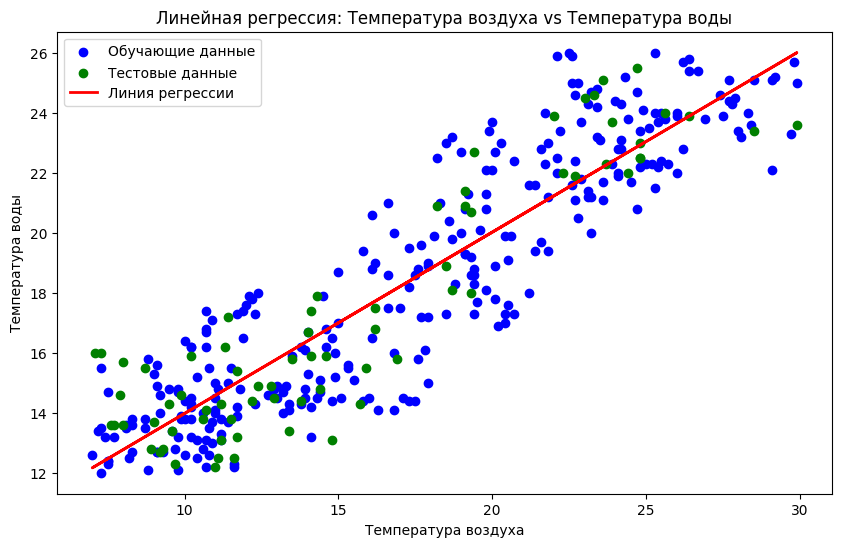

In [219]:
# Постройте график получившейся линии регрессии
plt.figure(figsize=(10, 6))
# plt.scatter(X, y, color='blue', label='Данные')
# plt.plot(X_train, model.predict(X_train), color='red', label='Линия регрессии')

plt.scatter(X_train, y_train, color = 'blue', label = 'Обучающие данные')
plt.scatter(X_test, y_test, color = 'green', label = 'Тестовые данные')
plt.plot(X_train, model.predict(X_train), color = 'red', linewidth = 2, label = 'Линия регрессии')

plt.xlabel('Температура воздуха')
plt.ylabel('Температура воды')
plt.title('Линейная регрессия: Температура воздуха vs Температура воды')
plt.legend()
plt.show()

In [220]:
# Сделайте прогнозы для тестового набора в переменную y_pred
y_pred = model.predict(X_test)
y_pred

array([22.20375421, 13.31179277, 15.00549971, 14.82403111, 14.88452065,
       23.41354488, 15.42892645, 17.54606012, 19.6631938 , 19.23976707,
       12.70689744, 14.94501018, 14.76354158, 14.64256251, 17.72752873,
       18.9373194 , 13.55375091, 19.60270427, 16.39675899, 16.75969619,
       12.52542884, 21.41739027, 16.88067526, 21.23592167, 21.65934841,
       22.92962861, 22.02228561, 19.118788  , 13.67472998, 14.09815671,
       14.58207298, 16.09431132, 12.58591837, 12.76738697, 26.01459483,
       16.63871712, 14.40060438, 14.70305205, 12.34396024, 16.45724852,
       23.89746115, 14.70305205, 13.37228231, 19.4817252 , 16.27577992,
       25.16774136, 16.45724852, 14.34011485, 13.49326137, 12.76738697,
       22.92962861, 12.22298117, 19.60270427, 19.4817252 , 22.68767048,
       13.91668811, 18.15095546, 13.73521951, 15.00549971, 15.73137412,
       22.86913908, 13.19081371, 15.30794738, 13.79570904, 22.92962861,
       16.03382179, 22.38522281, 17.72752873, 22.26424374, 15.67

##### <b><font color='lightcoral'>4. Оценка эффективности</font></b>

In [221]:
# Рассчитайте mse и r2 в переменные с теми же названиями
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}')
print(f'R2: {r2:.2f}')

MSE: 2.95
R2: 0.82


In [222]:
# Добавьте к входным данным (т.е. в переменную X) поле Wind, перестройте модель и посчитайте его эффективность
X_1 = df_weather[['AirTemp', 'Wind']]
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y, test_size=0.2, random_state=42)
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)
y_pred_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, y_pred_1)
r2_1 = r2_score(y_test_1, y_pred_1)
print(f'MSE с Wind: {mse_1:.2f}')
print(f'R2 с Wind: {r2_1:.2f}')


MSE с Wind: 2.93
R2 с Wind: 0.82


In [223]:
# Добавьте к входным данным (т.е. в переменную X) поле Rain, перестройте модель и посчитайте его эффективность
X_2 = df_weather[['AirTemp', 'Wind', 'Rain']]
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y, test_size=0.2, random_state=42)
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)
y_pred_2 = model_2.predict(X_test_2)
mse_2 = mean_squared_error(y_test_2, y_pred_2)
r2_2 = r2_score(y_test_2, y_pred_2)
print(f'MSE с Rain: {mse_2:.2f}')
print(f'R2 с Rain: {r2_2:.2f}')

MSE с Rain: 2.95
R2 с Rain: 0.82


In [224]:
# Постройте модель линейной регрессии для прогноза дождя, при известных: температуре воздуха, скорости ветра и температуре воды
X_class = df_weather[['AirTemp', 'Wind', 'WaterTemp']]
y_class = df_weather['Rain']
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
model_class = LinearRegression()
model_class.fit(X_train_class, y_train_class)
y_pred_class = model_class.predict(X_test_class)
mse_class = mean_squared_error(y_test_class, y_pred_class)
r2_class = r2_score(y_test_class, y_pred_class)
print(f'MSE: {mse_class:.2f}')
print(f'R2: {r2_class:.2f}')

MSE: 0.13
R2: 0.02


In [225]:
# Для задачи 4 постройте модель логистической регрессии
X_class = df_weather[['AirTemp', 'Wind', 'WaterTemp']]
y_class = df_weather['Rain']
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
model_class = LogisticRegression()
model_class.fit(X_train_class, y_train_class)
y_pred_class = model_class.predict(X_test_class)
accuracy = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {accuracy:.2f}')
print(classification_report(y_test_class, y_pred_class))


Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        62
           1       0.00      0.00      0.00        11

    accuracy                           0.85        73
   macro avg       0.42      0.50      0.46        73
weighted avg       0.72      0.85      0.78        73



c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.86      0.87      0.86        62
           1       0.20      0.18      0.19        11

    accuracy                           0.77        73
   macro avg       0.53      0.53      0.53        73
weighted avg       0.76      0.77      0.76        73



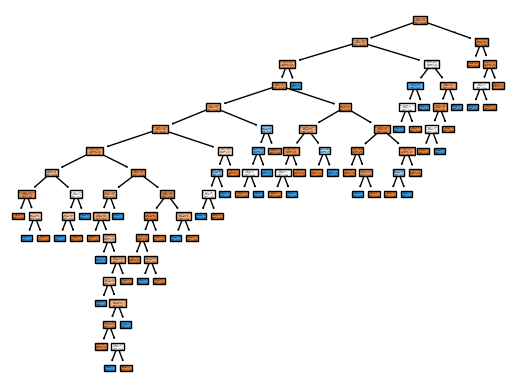

In [226]:
# Для задачи 4 постройте модель дерево решений.
X_class = df_weather[['AirTemp', 'Wind', 'WaterTemp']]
y_class = df_weather['Rain']
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
model_class = DecisionTreeClassifier()
model_class.fit(X_train_class, y_train_class)
y_pred_class = model_class.predict(X_test_class)
accuracy = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {accuracy:.2f}')
print(classification_report(y_test_class, y_pred_class))
plot_tree(model_class, feature_names=X_class.columns, class_names=['No Rain', 'Rain'], filled=True)
plt.show()

In [227]:
plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

### <b><font color='lightcoral'>Задача 2</font></b>
<b>Описание данных: </b><br>
Датасет California Housing содержит данные о ценах и других параметрах на жилье в Калифорнии.<br>

Поля:
- MedInc - медианный доход домохозяйства в block group
- HouseAge - медианный возраст домов (лет) в block group
- AveRooms - среднее число комнат на домохозяйство
- AveBedrms - среднее число спален
- Population - число людей в block group
- AveOccup - среднее число людей на домохозяйство
- Latitude - широта
- Longitude - долгота

Задача: 
1. Предсказать цены на дома на основе всех имеющихся характеристик

In [228]:
from sklearn.datasets import fetch_california_housing

In [229]:
# В переменную df_california запишите датасет fetch_california_housing
df_california = fetch_california_housing(as_frame=True).frame
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [257]:
# В переменную X запишите все данные из компонента data датасета
X_california = df_california.drop(columns='MedHouseVal')


In [258]:
# В переменную y запишите цену из компонента target датасета
y_california = df_california['MedHouseVal']

In [259]:
# В переменные X_train, X_test, y_train, y_test запишите обучающие и тестовые данные
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_california, y_california, test_size=0.2, random_state=42)

In [260]:
# Инициализируйте модель в переменную model
model_california = LinearRegression()

In [261]:
# Обучите модель на обучающих данных
model_california.fit(X_train_3, y_train_3)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [262]:
# Сделайте прогнозы для тестового набора в переменную y_pred
y_pred_california = model_california.predict(X_test_3)

In [263]:
# Рассчитайте mse и r2 в переменные с теми же названиями
mse = mean_squared_error(y_test_3, y_pred_california)
r2 = r2_score(y_test_3, y_pred_california)
print(f'MSE: {mse:.2f}')
print(f'R2: {r2:.2f}')

MSE: 0.56
R2: 0.58


In [288]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=35)
knn.fit(X_train_3, y_train_3)
y_pred_knn = knn.predict(X_test_3)
mse_knn = mean_squared_error(y_test_3, y_pred_knn)
r2_knn = r2_score(y_test_3, y_pred_knn)
print(f'MSE KNN: {mse_knn:.2f}')
print(f'R2 KNN: {r2_knn:.2f}')


MSE KNN: 1.19
R2 KNN: 0.09


In [289]:
# так теперь для дерева решений тоже самое по калифорнии
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_3, y_train_3)
y_pred_tree = tree.predict(X_test_3)
mse_tree = mean_squared_error(y_test_3, y_pred_tree)
r2_tree = r2_score(y_test_3, y_pred_tree)
print(f'MSE Decision Tree: {mse_tree:.2f}')
print(f'R2 Decision Tree: {r2_tree:.2f}')
plot_tree(tree, feature_names=X_california.columns, filled=True)
plt.show()

MSE Decision Tree: 0.49
R2 Decision Tree: 0.62


KeyboardInterrupt: 

### <b><font color='lightcoral'>Задача 3</font></b>
<b>Описание данных: </b><br>
Датасет mtcars.csv содержит данные о характеристиках автомобилей<br>

Поля:
- mpg - расход топлива (миль на галлон)
- cyl - число цилиндров
- disp - рабочий объём двигателя (кубические дюймы)
- hp - мощность двигателя
- drat - передаточное отношение заднего моста
- wt - масса автомобиля
- qsec - время проезда 1/4 мили (секунды)
- vs - двигатель: 0 = V-shaped, 1 = straight
- am - коробка передач: 0 = автомат, 1 = механика
- gear - число передач вперёд
- carb - число карбюраторов
- carname - название машины

Задача: 
1. Предсказать расход топлива для автомобилей на основе мощности, веса и количества цилиндров.

In [291]:
# Загрузите данные в датафрейм df_mtcars
df_mtcars = pd.read_csv('../data/mtcars.csv')
df_mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,carname
0,4.582576,6,160.0,110,3.90,2.62,16.46,0,1,4,4,Mazda RX4
1,4.582576,6,160.0,110,3.90,2875.00,17.02,0,1,4,4,Mazda RX4 Wag
2,4.774935,4,108.0,93,3.85,2.32,18.61,1,1,4,1,Datsun 710
3,4.626013,6,258.0,110,3.08,3215.00,19.44,1,0,3,1,Hornet 4 Drive
4,4.324350,8,360.0,175,3.15,3.44,17.02,0,0,3,2,Hornet Sportabout


In [292]:
# В переменную X запишите компонент входные характеристики для прогноза на основе мощности, веса и количества цилиндров
X_mtcars = df_mtcars[['hp', 'wt', 'cyl']]

In [293]:
# В переменную y запишите компонент расход топлива
y_mtcars = df_mtcars['mpg']

In [294]:
# Разделите данные на обучающую и тестовую выборки в переменные X_train, X_test, y_train, y_test
X_train_mtcars, X_test_mtcars, y_train_mtcars, y_test_mtcars = train_test_split(X_mtcars, y_mtcars, test_size=0.2, random_state=42)

In [295]:
# Инициализируйте модель в переменную model
model_mtcars = LinearRegression()

In [296]:
# Обучите модель на обучающих данных
model_mtcars.fit(X_train_mtcars, y_train_mtcars)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0. , 0. ,-0.23]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['hp','wt','cyl']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.196
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [297]:
# Сделайте прогнозы для тестового набора в переменную y_pred
y_pred_mtcars = model_mtcars.predict(X_test_mtcars)


In [298]:
# Рассчитайте mse и r2 в переменные с теми же названиями
mse_mtcars = mean_squared_error(y_test_mtcars, y_pred_mtcars)
r2_mtcars = r2_score(y_test_mtcars, y_pred_mtcars)
print(f'MSE: {mse_mtcars:.2f}')
print(f'R2: {r2_mtcars:.2f}')

MSE: 0.18
R2: 0.63


### <b><font color='lightcoral'>Задача 4</font></b>
<b>Описание данных: </b><br>
Датасет Breast Cancer содержит данные о различных параметрах опухоли. Параметры сгруппированы по 10 измерений, и для каждого из этих 10 есть 3 варианта: 
- mean
- se (standard error)
- worst (наихудшее значение в пределах ядра клетки)<br>

Поля:
- radius - среднее расстояние от центра до контурных точек
- texture - вариация в уровне серого на изображении
- perimeter - периметр контура
- area - площадь
- smoothness - локальная вариация радиуса (насколько “неровные” границы)
- compactness - (perimeter² / area) – 1.0
- concavity - степень вогнутости частей контура
- concave points - количество “впуклых” точек контура
- symmetry - симметричность
- fractal dimension - фрактальная размерность

Задача: 
1. Предсказать, является ли опухоль злокачественной или доброкачественной, основываясь на всех известных признаках.

In [314]:
# Из библиотеки sklearn загрузите набор данных Breast Cancer в переменную breast_cancer
from sklearn.datasets import load_breast_cancer
breast_cancer = load_breast_cancer(as_frame=True)
df_breast_cancer = breast_cancer.frame
df_breast_cancer.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [315]:
# В переменную X запишите компонент data из набора данных breast_cancer
X_breast_cancer = breast_cancer.data

In [316]:
# В переменную y запишите компонент target из набора данных breast_cancer
y_breast_cancer = breast_cancer.target

In [317]:
# Разделите данные на обучающую и тестовую выборки в переменные X_train, X_test, y_train, y_test
# Используйте стратификацию
X_train_bre, X_test_bre, y_train_bre, y_test_bre = train_test_split(X_breast_cancer, y_breast_cancer, test_size=0.2, random_state=42, stratify=y_breast_cancer)

In [328]:
# Инициализируйте модель в переменную model
model_bre = LogisticRegression(max_iter=5000)

In [329]:
# Обучите модель на обучающих данных
model_bre.fit(X_train_bre, y_train_bre)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [330]:
# Сделайте прогнозы для тестового набора в переменную y_pred
y_pred_bre = model_bre.predict(X_test_bre)

In [332]:
# Рассчитайте эффективность прогноза
accuracy_bre = accuracy_score(y_test_bre, y_pred_bre)
print(f'Accuracy: {accuracy_bre:.2f}')
print(classification_report(y_test_bre, y_pred_bre))

Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

